In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

CUDA available: True
Torch CUDA version: 11.8
GPU: NVIDIA GeForce GTX 1650


In [3]:
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2

In [4]:
base_transform = v2.Compose([
    v2.Resize((128,128)),
    v2.ToImage(), # replaces the old toTensor()
    v2.ToDtype(torch.float32, scale=True)
])

In [5]:
data = datasets.ImageFolder(root='Deepfake-vs-Real-v2',transform=base_transform)

In [6]:
type(data.imgs)

list

In [68]:
data.classes

['Deepfake', 'Real']

In [70]:
import torch

targets = torch.tensor(data.targets)        # [N] numeric labels
unique_classes, counts = torch.unique(targets, return_counts=True)

for cls, cnt in zip(unique_classes, counts):
    print(f"Class {cls.item()}: {cnt.item()} samples")

Class 0: 9574 samples
Class 1: 9713 samples


In [7]:
data.imgs

[('Deepfake-vs-Real-v2\\Deepfake\\111 (1).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (10).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (100).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1000).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1001).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1002).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1003).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1004).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1005).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1006).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1007).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1008).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1009).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (101).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1010).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1011).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1012).jpg', 0),
 ('Deepfake-vs-Real-v2\\Deepfake\\111 (1013).jpg', 0),
 ('Deepfake-vs-Re

In [8]:
type(data.classes)

list

In [9]:
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

targets = data.targets

train_idx, test_idx = train_test_split(
    range(len(data)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(data, train_idx)
test_dataset = Subset(data, test_idx)

In [10]:
train_dataset[1]

(Image([[[0.2392, 0.2314, 0.2314,  ..., 0.8353, 0.8431, 0.8510],
         [0.2000, 0.1961, 0.1882,  ..., 0.8392, 0.8431, 0.8431],
         [0.1529, 0.1490, 0.1451,  ..., 0.8431, 0.8471, 0.8471],
         ...,
         [0.2157, 0.2392, 0.2863,  ..., 0.3412, 0.3451, 0.3725],
         [0.2549, 0.2157, 0.2706,  ..., 0.3373, 0.3608, 0.3686],
         [0.2392, 0.2118, 0.2549,  ..., 0.2980, 0.3255, 0.3608]],
 
        [[0.2196, 0.2157, 0.2157,  ..., 0.8235, 0.8275, 0.8275],
         [0.1882, 0.1882, 0.1843,  ..., 0.8314, 0.8314, 0.8275],
         [0.1529, 0.1490, 0.1490,  ..., 0.8392, 0.8392, 0.8353],
         ...,
         [0.1765, 0.1843, 0.2157,  ..., 0.2275, 0.2275, 0.2471],
         [0.1961, 0.1608, 0.2000,  ..., 0.2275, 0.2471, 0.2549],
         [0.1804, 0.1529, 0.1922,  ..., 0.1882, 0.2196, 0.2549]],
 
        [[0.1843, 0.1804, 0.1804,  ..., 0.7843, 0.7843, 0.7882],
         [0.1608, 0.1608, 0.1569,  ..., 0.8039, 0.7961, 0.7882],
         [0.1333, 0.1294, 0.1333,  ..., 0.8196, 0.8157, 

In [11]:
class dataAugmentationTrain(Dataset):
    def __init__(self,data):
        super().__init__()
        self.data = data
        self.preprocess= v2.Compose([
            v2.RandomHorizontalFlip(),  
            v2.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]   
            )
        ])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        image,label = self.data[index]
        return self.preprocess(image), torch.tensor(label)

In [12]:
class dataAugmentationTest(Dataset):
    def __init__(self,data):
        super().__init__()
        self.data = data
        self.preprocess= v2.Compose([
            v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        image,label = self.data[index]
        return self.preprocess(image), torch.tensor(label)

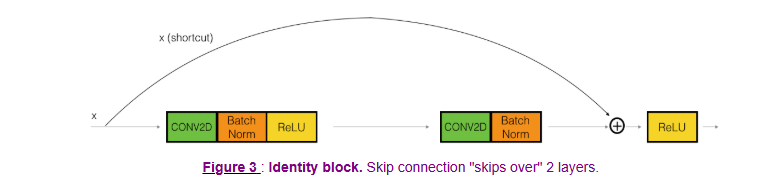

In [13]:
class identityBlock(nn.Module):
    def __init__(self,inchannels,f,filters):
        super().__init__()
        self.f1,self.f2,self.f3 = filters
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=inchannels,out_channels=self.f1,kernel_size=1,stride=1,padding='valid'),
            nn.BatchNorm2d(self.f1),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=self.f1,out_channels=self.f2,kernel_size=f,stride=1,padding='same',padding_mode='zeros'),
            nn.BatchNorm2d(self.f2),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=self.f2,out_channels=self.f3,kernel_size=1,stride=1,padding='valid'),
            nn.BatchNorm2d(self.f3)
        )
    def forward(self,x):
        x_shortcut = x
        
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x = torch.add(x_shortcut,x)
        x = F.relu(x)

        return x

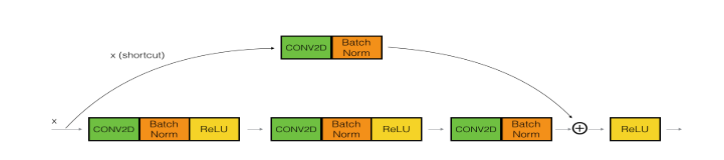

In [14]:
class convolutionalBlock(nn.Module):
    def __init__(self,inchannels,f,filters,s=2):
        super().__init__()
        self.f1,self.f2,self.f3 = filters
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=inchannels,out_channels=self.f1,kernel_size=1,stride=s,padding='valid'),
            nn.BatchNorm2d(self.f1),
            nn.ReLU()
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=self.f1,out_channels=self.f2,kernel_size=f,stride=1,padding='same'),
            nn.BatchNorm2d(self.f2),
            nn.ReLU()
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(in_channels=self.f2,out_channels=self.f3,kernel_size=1,stride=1,padding='valid'),
            nn.BatchNorm2d(self.f3)
        )
        self.shortcut_block = nn.Sequential(
            nn.Conv2d(in_channels=inchannels,out_channels=self.f3,kernel_size=1,stride=s,padding='valid'),
            nn.BatchNorm2d(self.f3)
        )
    def forward(self,x):

        x_shortcut = x
        
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)

        x_shortcut = self.shortcut_block(x_shortcut)

        x = torch.add(x_shortcut,x)
        x = F.relu(x)

        return x
        


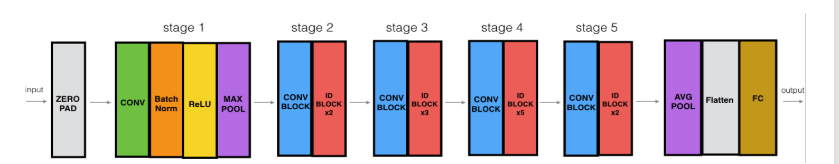

In [15]:
class ResNet50(nn.Module):
    def __init__(self, classes):
        super().__init__()

        self.model = nn.Sequential(
            
            nn.ZeroPad2d(padding=3),

            #stage1
            nn.Conv2d(in_channels=3,out_channels=64,kernel_size=(7,7),stride=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),

            #stage2
            convolutionalBlock(64,3,[64,64,256],1),
            identityBlock(256,3,[64,64,256]),
            identityBlock(256,3,[64,64,256]),

            #stage3
            convolutionalBlock(256,3,[128,128,512],2),
            identityBlock(512,3,[128,128,512]),
            identityBlock(512,3,[128,128,512]),
            identityBlock(512,3,[128,128,512]),

            #stage4
            convolutionalBlock(512,3,[256, 256, 1024],2),
            identityBlock(1024,3,[256, 256, 1024]),
            identityBlock(1024,3,[256, 256, 1024]),
            identityBlock(1024,3,[256, 256, 1024]),
            identityBlock(1024,3,[256, 256, 1024]),
            identityBlock(1024,3,[256, 256, 1024]),

            #stage5
            convolutionalBlock(1024,3,[512, 512, 2048],2),
            identityBlock(2048,3,[512, 512, 2048]),
            identityBlock(2048,3,[512, 512, 2048]),

            nn.AdaptiveAvgPool2d((1,1)) 
        )
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(2048,classes)
    
    def forward(self,x):
        x = self.model(x)
        x = self.flatten(x)
        y_hat = self.fc(x)

        return y_hat

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [17]:
device

device(type='cuda')

In [18]:
import torch.optim as optim

In [19]:
model = ResNet50(1).to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(lr=0.0001,params=model.parameters())

In [20]:
train_loader = DataLoader(dataAugmentationTrain(train_dataset),batch_size=32,shuffle=True)
test_loader = DataLoader(dataAugmentationTest(test_dataset),batch_size=32,shuffle=False)

In [21]:
# epochs = 10

# for epoch in range(epochs):
#     model.train()
#     total_loss_per_epoch = 0
#     for batch_features, batch_labels in train_loader:

#         batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
#         batch_labels = batch_labels.float().unsqueeze(1)

#         #forward_pass
#         y_hat = model(batch_features)
#         loss = loss_fn(y_hat,batch_labels)

#         #back_pass
#         optimizer.zero_grad()
#         loss.backward()

#         #update gradients
#         optimizer.step()
#         total_loss_per_epoch  += loss.item()

#     avg_loss = total_loss_per_epoch / len(train_loader)
#     print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

In [22]:
import torch
import time

def train_model(model, train_loader, loss_fn, optimizer, epochs, device):
    print(f"Starting training on {device}...")
    start_of_all_training = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss_per_epoch = 0
        last_batch_end_time = time.time()

        for i, (batch_features, batch_labels) in enumerate(train_loader):

            load_duration = time.time() - last_batch_end_time
            if epoch == 0:
                print(f"Batch {i} | Load Time: {load_duration:.4f}s")



            # Move to GPU
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device).float().unsqueeze(1)

            #forward_pass
            y_hat = model(batch_features)
            loss = loss_fn(y_hat,batch_labels)

            #back_pass
            optimizer.zero_grad()
            loss.backward()

            #update gradients
            optimizer.step()
            total_loss_per_epoch  += loss.item()

            last_batch_end_time = time.time()


        avg_loss = total_loss_per_epoch / len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} Complete | Loss: {avg_loss:.4f}")

    print(f"Total Training Finished in {time.time() - start_of_all_training:.2f}s")


if __name__ == '__main__':
    train_model(model, train_loader, loss_fn, optimizer, epochs=10, device=device)

Starting training on cuda...
Batch 0 | Load Time: 3.2203s
Batch 1 | Load Time: 2.2861s
Batch 2 | Load Time: 2.6523s
Batch 3 | Load Time: 2.2211s
Batch 4 | Load Time: 2.6553s
Batch 5 | Load Time: 2.6550s
Batch 6 | Load Time: 2.0852s
Batch 7 | Load Time: 2.7068s
Batch 8 | Load Time: 2.1607s
Batch 9 | Load Time: 2.7694s
Batch 10 | Load Time: 2.8688s
Batch 11 | Load Time: 2.9475s
Batch 12 | Load Time: 2.1136s
Batch 13 | Load Time: 2.1864s
Batch 14 | Load Time: 1.4907s
Batch 15 | Load Time: 2.5439s
Batch 16 | Load Time: 1.9609s
Batch 17 | Load Time: 1.9993s
Batch 18 | Load Time: 1.8480s
Batch 19 | Load Time: 2.6431s
Batch 20 | Load Time: 1.8369s
Batch 21 | Load Time: 1.8480s
Batch 22 | Load Time: 1.6966s
Batch 23 | Load Time: 1.8092s
Batch 24 | Load Time: 1.8804s
Batch 25 | Load Time: 2.1555s
Batch 26 | Load Time: 3.6680s
Batch 27 | Load Time: 1.8579s
Batch 28 | Load Time: 2.3229s
Batch 29 | Load Time: 2.3490s
Batch 30 | Load Time: 1.9418s
Batch 31 | Load Time: 1.8145s
Batch 32 | Load Time:

In [23]:
torch.save(model.state_dict(), "resnet50_deepfake_classification.pth")

In [66]:
model.eval()
total = 0
correct = 0 

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        
        # 1. Get raw logits from model
        outputs = model(batch_features).squeeze() # Turn [batch, 1] into [batch]
        
        # 2. If logit > 0, it's Class 1. If logit <= 0, it's Class 0.
        predicted = (outputs > 0.0).float()
        
        # 3. Count accuracy
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f"Real Test accuracy: {100 * correct / total:.2f}%")

Real Test accuracy: 96.11%


In [63]:
model.eval()
total = 0
correct = 0 

with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        
        # 1. Get raw logits from model
        outputs = model(batch_features).squeeze() # Turn [batch, 1] into [batch]
        
        # 2. If logit > 0, it's Class 1. If logit <= 0, it's Class 0.
        predicted = (outputs > 0.5).float()
        
        # 3. Count accuracy
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

print(f"Real Test accuracy: {100 * correct / total:.2f}%")

Real Test accuracy: 96.27%


In [64]:
img,lbl = test_loader.dataset[6]

In [67]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

all_labels = []
all_preds = []
all_logits = []

model.eval()
with torch.no_grad():
    for batch_features, batch_labels in test_loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device).float()
        
        outputs = model(batch_features).view(-1)          
        predicted = (outputs > 0.0).float()               
        
        all_labels.append(batch_labels.cpu())
        all_preds.append(predicted.cpu())
        all_logits.append(outputs.cpu())

# Concatenate all batches
all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()
all_logits = torch.cat(all_logits).numpy()

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds)
recall = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)
roc_auc = roc_auc_score(all_labels, all_logits)  # use logits or sigmoid outputs

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")
print(f"AUROC: {roc_auc:.4f}")

Accuracy: 96.11%
Precision: 95.95%
Recall: 96.35%
F1-score: 96.15%
AUROC: 0.9918


In [65]:
model.eval()
with torch.no_grad():
    output = model(img.unsqueeze(0).to(device))
    _, pred = torch.max(output, 1)

print(f"Prediction: {pred.item()}")
print(f"Actual Label from Dataset: {lbl}")

Prediction: 0
Actual Label from Dataset: 0
